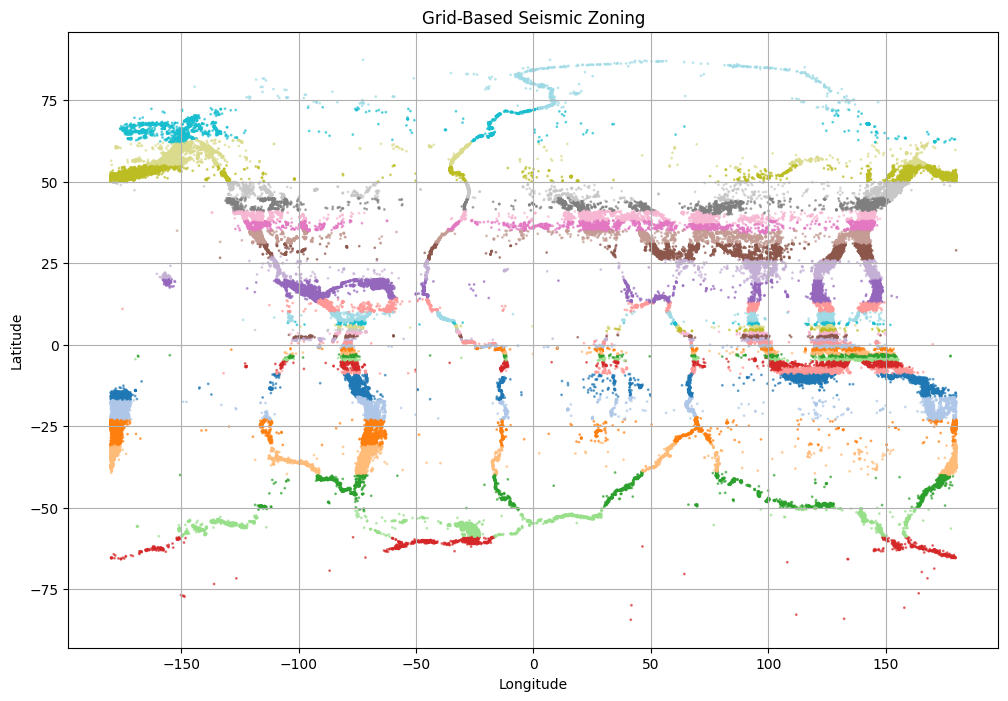

In [1]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv("C:/Users/theta/Downloads/cleaned_earthquakes.csv")  # Replace with your actual file path
df = df.drop('seismic_zone', axis=1) # axis=1 indicates dropping a column

# Define grid resolution (in degrees)
grid_size = 1.0  # You can tune this later

# Create grid bins
df['lat_bin'] = np.floor(df['latitude'] / grid_size).astype(int)
df['lon_bin'] = np.floor(df['longitude'] / grid_size).astype(int)

# Create a unique grid ID
df['grid_id'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

# Group by grid_id and compute both metrics
grid_stats = df.groupby('grid_id').agg({
    'mag': ['max', 'mean', 'count']
}).reset_index()

# Rename columns for clarity
grid_stats.columns = ['grid_id', 'max_mag', 'mean_mag', 'event_count']

# Define weights (you can tune these later)
# w_max = 0.7
# w_mean = 0.3

# # Compute hybrid score
# grid_stats['zone_score'] = w_max * grid_stats['max_mag'] + w_mean * grid_stats['mean_mag'] #for this, the function should have score instead of mag

def assign_seismic_zone(mag):
    if mag < 5.0:
        return 'Low'
    elif 5.0 <= mag < 6.0:
        return 'Moderate'
    elif 6.0 <= mag < 7.0:
        return 'High'
    else:
        return 'Very High'

grid_stats['seismic_zone'] = grid_stats['max_mag'].apply(assign_seismic_zone)
df = df.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')
# grid_stats['seismic_zone'] = grid_stats['zone_score'].apply(assign_seismic_zone)
# df = df.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')

import matplotlib.pyplot as plt

# Plot earthquake density by grid
plt.figure(figsize=(12, 8))
plt.scatter(df['longitude'], df['latitude'], c=df['grid_id'].astype('category').cat.codes,
            cmap='tab20', s=1, alpha=0.6)
plt.title('Grid-Based Seismic Zoning')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

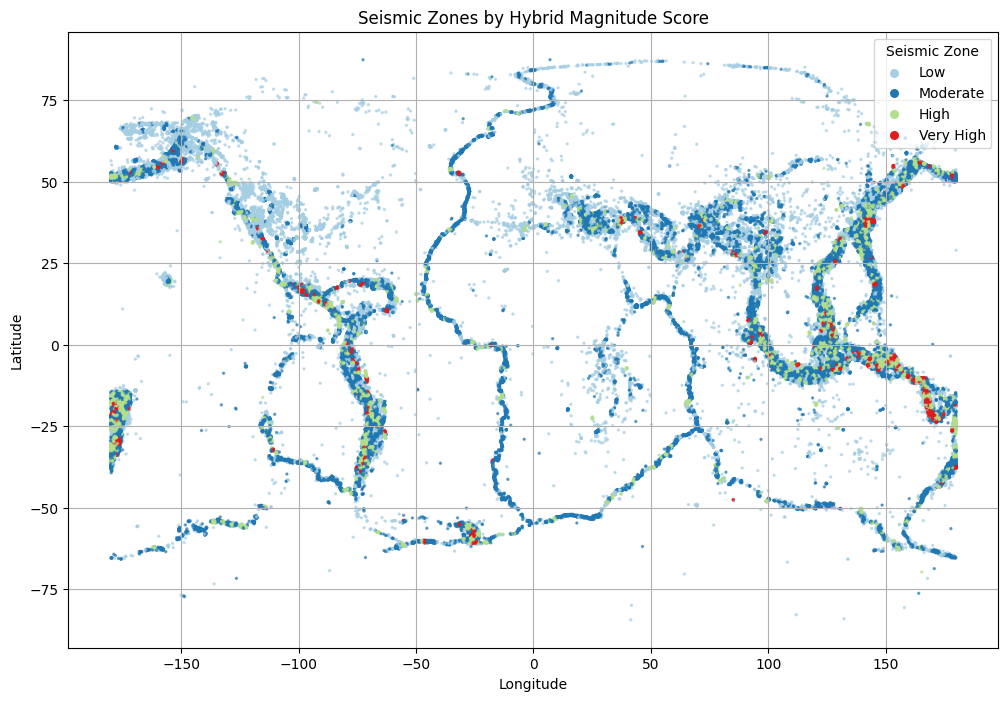

In [2]:
import matplotlib.pyplot as plt

# Define a color map for seismic zones
zone_colors = {
    'Low': '#a6cee3',
    'Moderate': '#1f78b4',
    'High': '#b2df8a',
    'Very High': '#e31a1c'
}

# Map colors to each row
df['zone_color'] = df['seismic_zone'].map(zone_colors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(df['longitude'], df['latitude'], c=df['zone_color'], s=2, alpha=0.6)
plt.title('Seismic Zones by Hybrid Magnitude Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)

# Create legend
for zone, color in zone_colors.items():
    plt.scatter([], [], c=color, label=zone, s=30)
plt.legend(title='Seismic Zone', loc='upper right')

plt.show()

seismic_zone
Low          4867
Moderate     2720
High          788
Very High     174
Name: count, dtype: int64


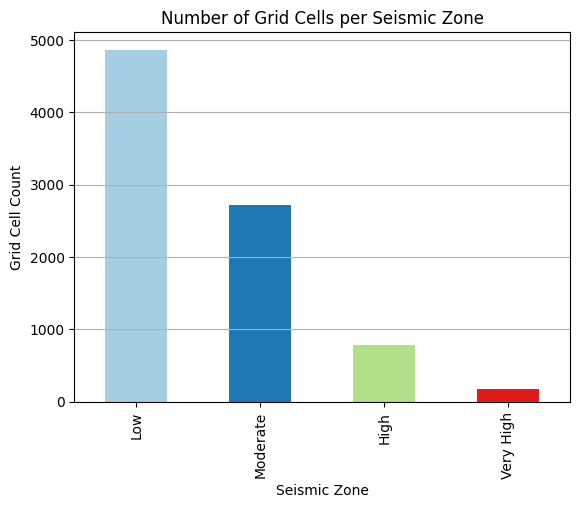

In [12]:
grid_counts = grid_stats['seismic_zone'].value_counts()

zone_order = ['Low', 'Moderate', 'High', 'Very High']
grid_counts = grid_counts.reindex(zone_order)

print(grid_counts)

import matplotlib.pyplot as plt

grid_counts.plot(kind='bar', color=['#a6cee3', '#1f78b4', '#b2df8a', '#e31a1c'])
plt.title('Number of Grid Cells per Seismic Zone')
plt.xlabel('Seismic Zone')
plt.ylabel('Grid Cell Count')
plt.grid(axis='y')
plt.show()

KNN:               precision    recall  f1-score   support

        High       0.96      0.98      0.97     17146
         Low       0.94      0.85      0.90      5399
    Moderate       0.95      0.96      0.95     18124
   Very High       0.97      0.98      0.97      7954

    accuracy                           0.96     48623
   macro avg       0.96      0.94      0.95     48623
weighted avg       0.96      0.96      0.96     48623

Random Forest:               precision    recall  f1-score   support

        High       0.99      0.99      0.99     17146
         Low       0.97      0.91      0.94      5399
    Moderate       0.97      0.99      0.98     18124
   Very High       1.00      0.99      0.99      7954

    accuracy                           0.98     48623
   macro avg       0.98      0.97      0.97     48623
weighted avg       0.98      0.98      0.98     48623



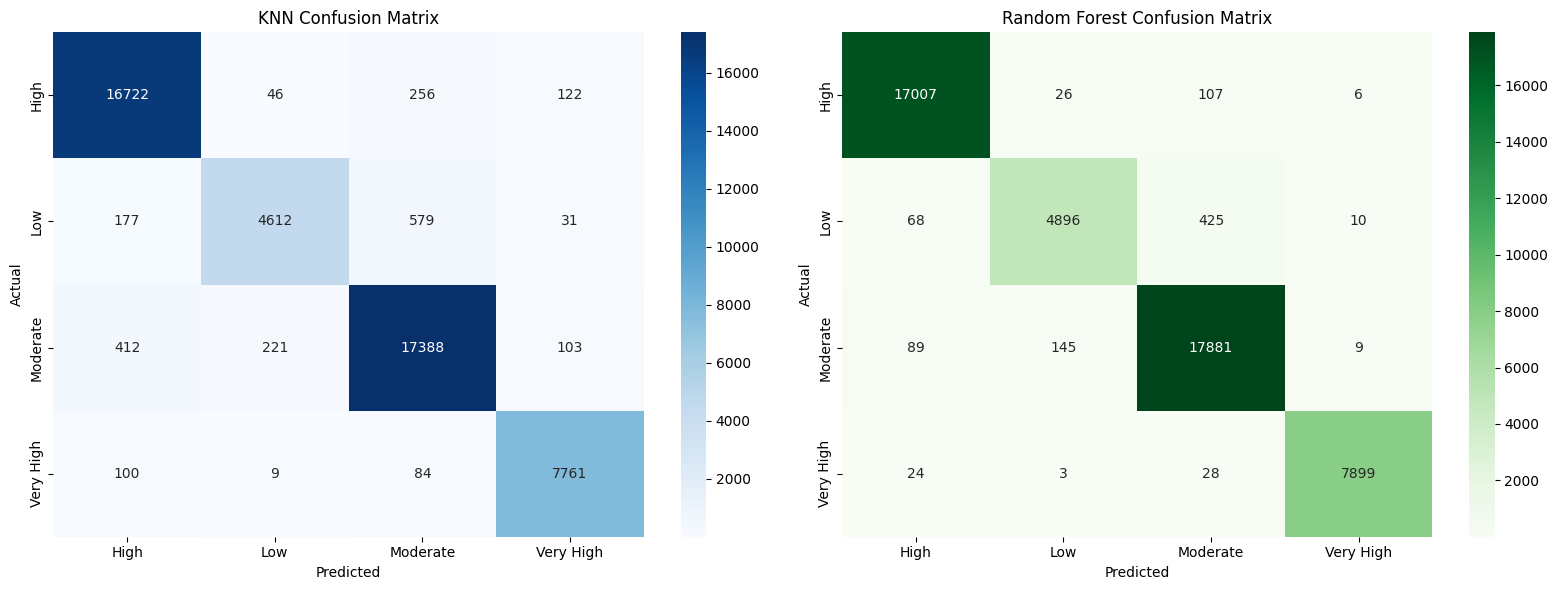

In [10]:
from sklearn.preprocessing import LabelEncoder

# Encode seismic zones as numeric labels
le = LabelEncoder()
df['zone_label'] = le.fit_transform(df['seismic_zone'])

# Features and labels
X = df[['latitude', 'longitude']]
y = df['zone_label']

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose model
modelK = KNeighborsClassifier(n_neighbors=5)
modelR = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
modelK.fit(X_train, y_train)
modelR.fit(X_train, y_train)

from sklearn.metrics import classification_report
y_predK = modelK.predict(X_test)
report = classification_report(y_test, y_predK, target_names=le.classes_)
print("KNN:", report)

y_predR = modelR.predict(X_test)
report2 = classification_report(y_test, y_predR, target_names=le.classes_)
print("Random Forest:", report2)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_predK)
cm_rf = confusion_matrix(y_test, y_predR)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


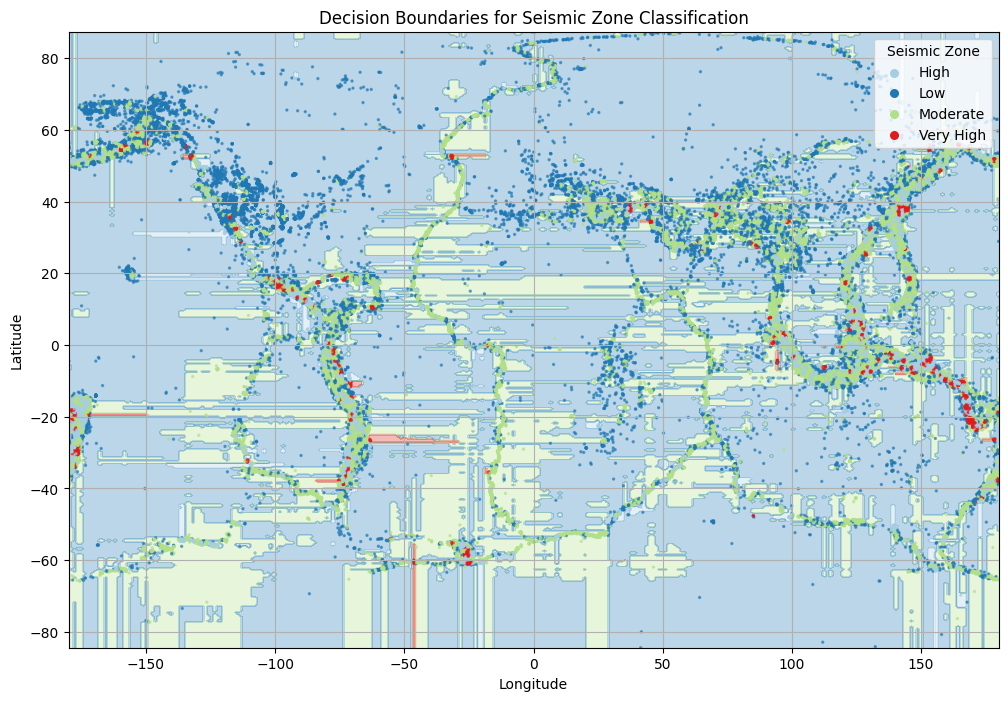

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define bounds based on your data
lat_min, lat_max = df['latitude'].min(), df['latitude'].max()
lon_min, lon_max = df['longitude'].min(), df['longitude'].max()

# Create meshgrid
lat_range = np.linspace(lat_min, lat_max, 300)
lon_range = np.linspace(lon_min, lon_max, 300)
lon_grid, lat_grid = np.meshgrid(lon_range, lat_range)

# Flatten and stack for prediction
grid_points = np.c_[lat_grid.ravel(), lon_grid.ravel()]  # shape: (N, 2) with [lat, lon]

# Predict using your trained model
grid_preds = modelR.predict(grid_points) #switch to modelK for KNN
grid_preds = grid_preds.reshape(lat_grid.shape)  # reshape to match meshgrid

# Define color map
zone_palette = ['#a6cee3', '#1f78b4', '#b2df8a', '#e31a1c']  # Adjust if needed
cmap = ListedColormap(zone_palette[:len(le.classes_)])

# Plot decision boundaries
plt.figure(figsize=(12, 8))
plt.contourf(lon_grid, lat_grid, grid_preds, cmap=cmap, alpha=0.3)

# Overlay actual earthquake points
plt.scatter(df['longitude'], df['latitude'], c=df['zone_label'], cmap=cmap, s=2, alpha=0.6)

# Add legend
for i, zone in enumerate(le.classes_):
    plt.scatter([], [], c=zone_palette[i], label=zone, s=30)
plt.legend(title='Seismic Zone', loc='upper right')

plt.title('Decision Boundaries for Seismic Zone Classification')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [26]:
def predict_zone_from_coords(lat, lon, model=modelR, label_encoder=le):
    coords = np.array([[lat, lon]])
    label = model.predict(coords)[0]
    zone = label_encoder.inverse_transform([label])[0]
    
    # Optional: confidence score
    if hasattr(model, "predict_proba"):
        confidence = float(np.max(model.predict_proba(coords)))  # Convert np.float64 to native float
    else:
        confidence = None
    
    # Format output
    if confidence is not None:
        print(f"📍 Location ({lat}, {lon}) is classified as '{zone}' with confidence {confidence:.2f}")
    else:
        print(f"📍 Location ({lat}, {lon}) is classified as '{zone}'")

# Example usage
predict_zone_from_coords(-22,170)



📍 Location (-22, 170) is classified as 'Very High' with confidence 0.56


C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
